⏳ Loading target dataset: '1) iris.csv'...
✔️ Split complete. Training with 105 samples; testing with 45 samples.
⚙️ Training structural Decision Tree Classifier...

             DECISION TREE EVALUATION SCORECARD
Overall Test Accuracy: 97.78%
-------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45

-------------------------------------------------------
Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]

📊 Rendering tree structural logic branching flow diagram...


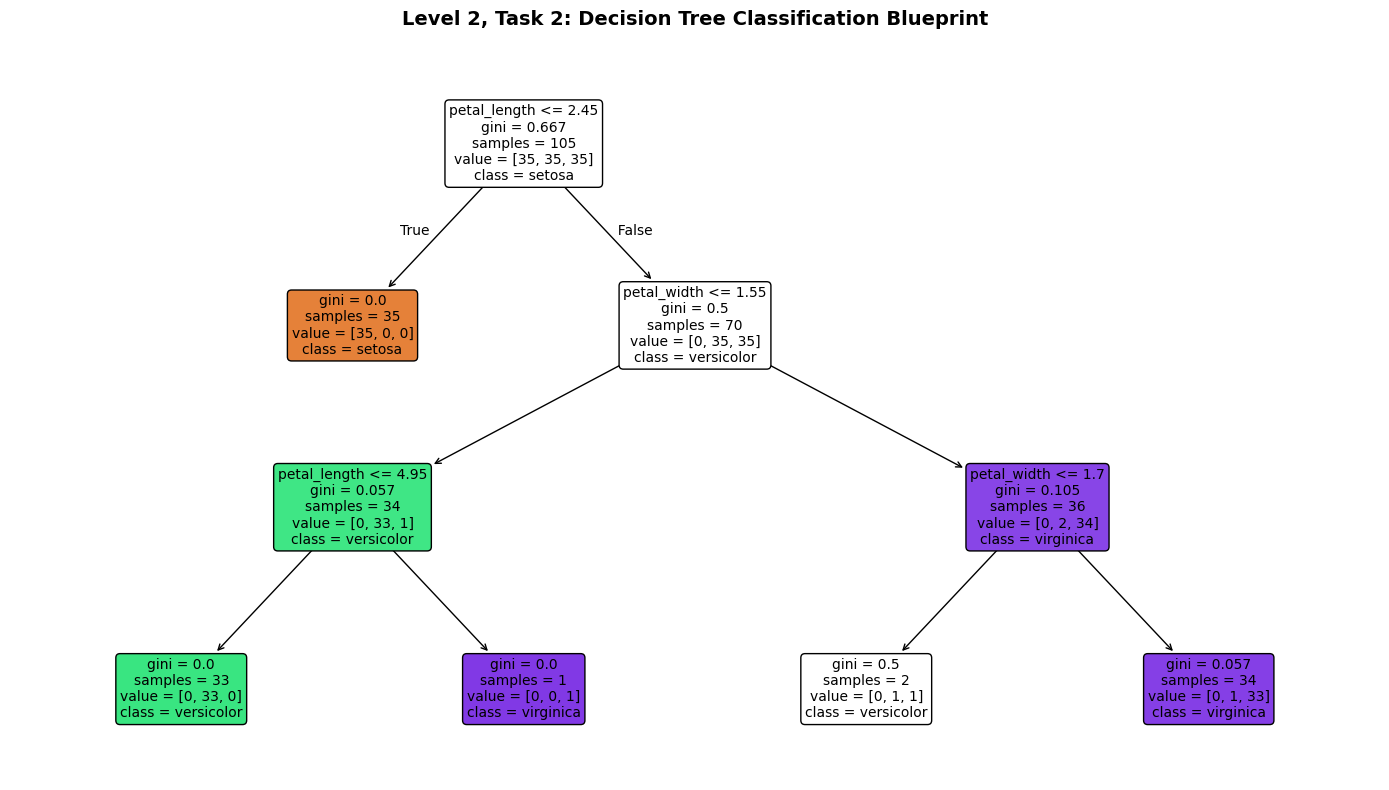


✔️ Process complete! Review the plotted diagram to see your model's exact rules.


In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# =====================================================================
# 1. DATA INGESTION & TARGET SEPARATION
# =====================================================================
filename = '1) iris.csv'

if not os.path.exists(filename):
    raise FileNotFoundError(
        f"Missing dataset file '{filename}' in directory '{os.getcwd()}'. "
        f"Please verify it is uploaded to your environment."
    )

print(f"⏳ Loading target dataset: '{filename}'...")
df_iris = pd.read_csv(filename)

# Isolate features (X) and target class labels (y)
X = df_iris.drop(columns=['species'])
y = df_iris['species']

# Stratify the train/test split to maintain perfect species ratios in both groups
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"✔️ Split complete. Training with {len(X_train)} samples; testing with {len(X_test)} samples.")

# =====================================================================
# 2. TRAINING THE ARCHITECTURE WITH PRE-PRUNING
# =====================================================================
print("⚙️ Training structural Decision Tree Classifier...")

# SENIOR INSIGHT: Setting max_depth=3 prevents the tree from growing
# infinitely deep and overfitting on minor outliers.
model_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

model_tree.fit(X_train, y_train)

# =====================================================================
# 3. EVALUATION MATRIX SCORECARD
# =====================================================================
y_pred = model_tree.predict(X_test)

print("\n" + "="*55)
print("             DECISION TREE EVALUATION SCORECARD")
print("="*55)
print(f"Overall Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("-"*55)
print(classification_report(y_test, y_pred))
print("-"*55)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("="*55)

# =====================================================================
# 4. STRUCTURAL TREE DIAGRAM VISUALIZATION
# =====================================================================
print("\n📊 Rendering tree structural logic branching flow diagram...")

plt.figure(figsize=(14, 8), dpi=100)
plot_tree(
    model_tree,
    feature_names=X.columns.tolist(),
    class_names=model_tree.classes_.tolist(),
    filled=True,             # Colors nodes based on their dominant category class
    rounded=True,            # Rounds the corners of the node boxes for readability
    impurity=True,           # Prints out the Gini impurity value at every branch step
    fontsize=10
)

plt.title("Level 2, Task 2: Decision Tree Classification Blueprint", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✔️ Process complete! Review the plotted diagram to see your model's exact rules.")